#              __________________________   * Flight Price Prediction * __________________________

# Import Liberaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [2]:
df = pd.read_csv('Flight_Booking.csv')
df = df.drop(columns=['Unnamed: 0'])
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


# Check Missing Values, Duplicates, Summary

In [3]:
df.isnull().sum().sum()

np.int64(0)

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


# Check Columns , shape, info

In [6]:
df.columns

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [7]:
df.shape

(300153, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [9]:
df.dtypes

,0
airline,object
flight,object
source_city,object
departure_time,object
stops,object
arrival_time,object
destination_city,object
class,object
duration,float64
days_left,int64


# Data Visualization

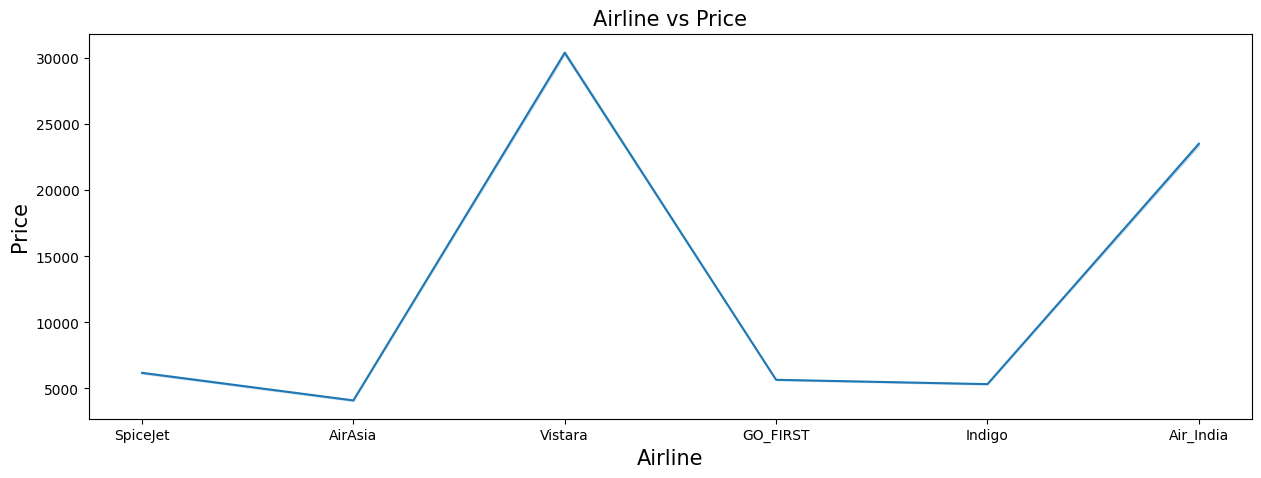

In [10]:
plt.figure(figsize=(15,5))
sns.lineplot(x=df['airline'], y=df['price'])
plt.title('Airline vs Price', fontsize = 15)
plt.xlabel('Airline',fontsize=15)
plt.ylabel('Price',fontsize=15)
plt.show()

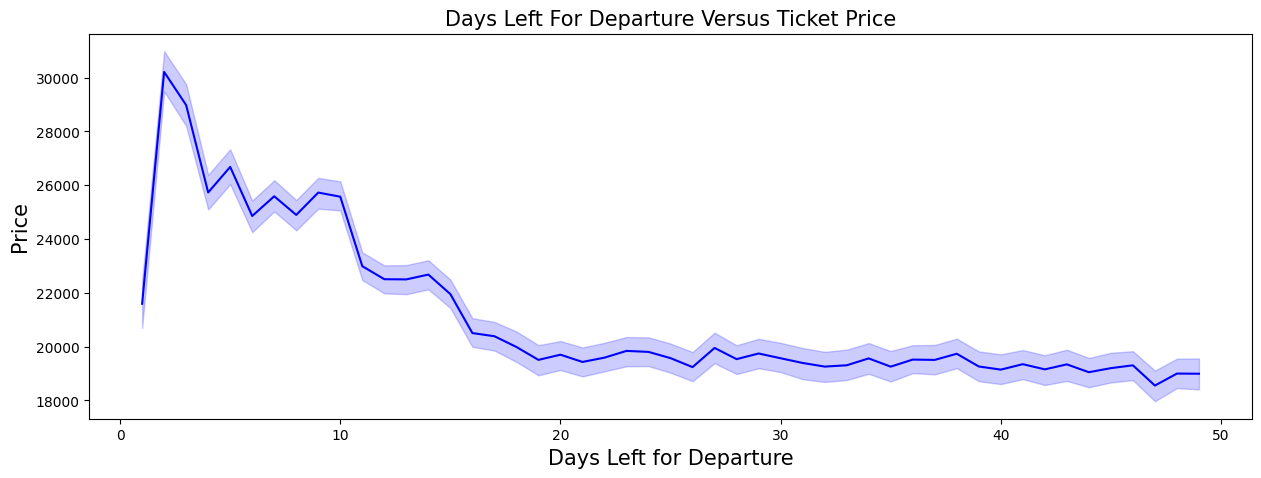

In [11]:
plt.figure(figsize=(15,5))
sns.lineplot(data=df, x='days_left', y = 'price', color = 'blue')
plt.title('Days Left For Departure Versus Ticket Price', fontsize = 15)
plt.xlabel('Days Left for Departure', fontsize = 15)
plt.ylabel('Price', fontsize=15)
plt.show()

# Price range of all the flights

<Axes: xlabel='airline', ylabel='price'>

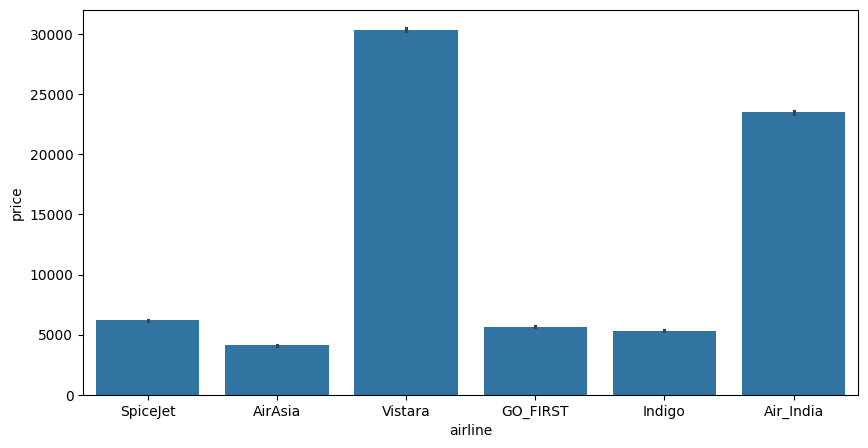

In [12]:
plt.figure(figsize=(10,5));
sns.barplot(x='airline', y='price', data = df)

# Range of price of all the flights of Economy and Business Class

<Axes: xlabel='class', ylabel='price'>

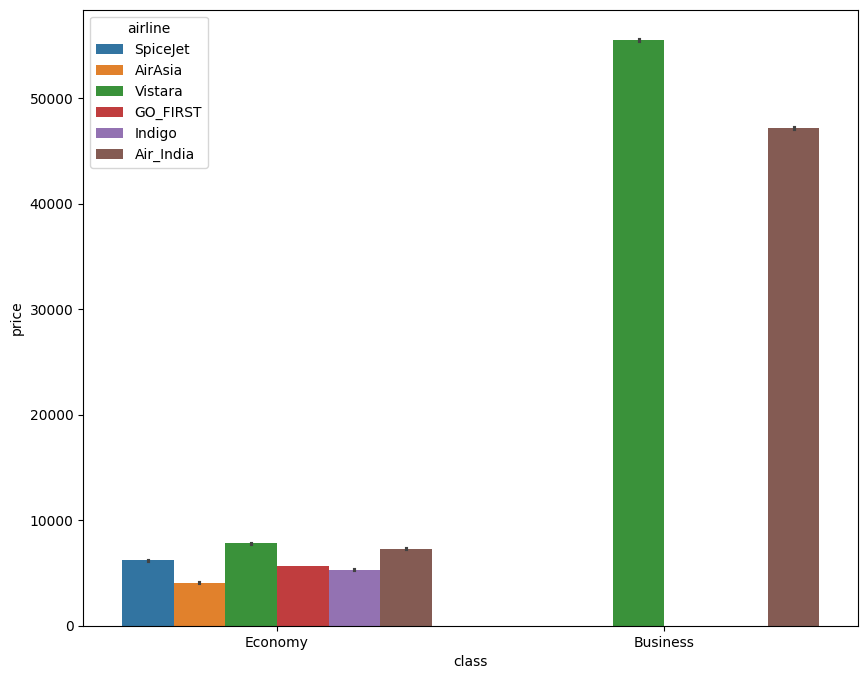

In [13]:
plt.figure(figsize=(10,8));
sns.barplot(x ='class' , y = 'price', data = df, hue = 'airline')

# Range of price of flights with source and destination city according to the days left

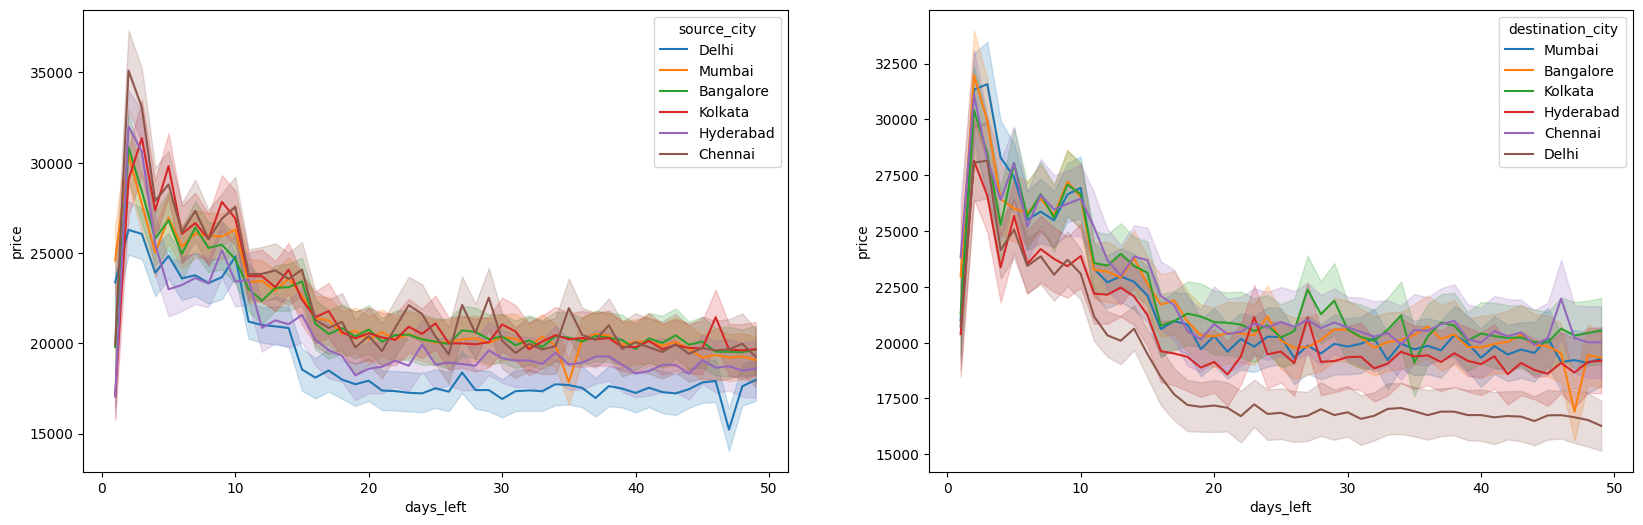

In [14]:
fig, ax=plt.subplots(1,2,figsize=(20,6))
sns.lineplot(x='days_left',y='price', data=df, hue='source_city', ax=ax[0])
sns.lineplot(x='days_left',y='price', data=df, hue='destination_city', ax=ax[1])
plt.show()

# Visualization of Categorical features with countplot

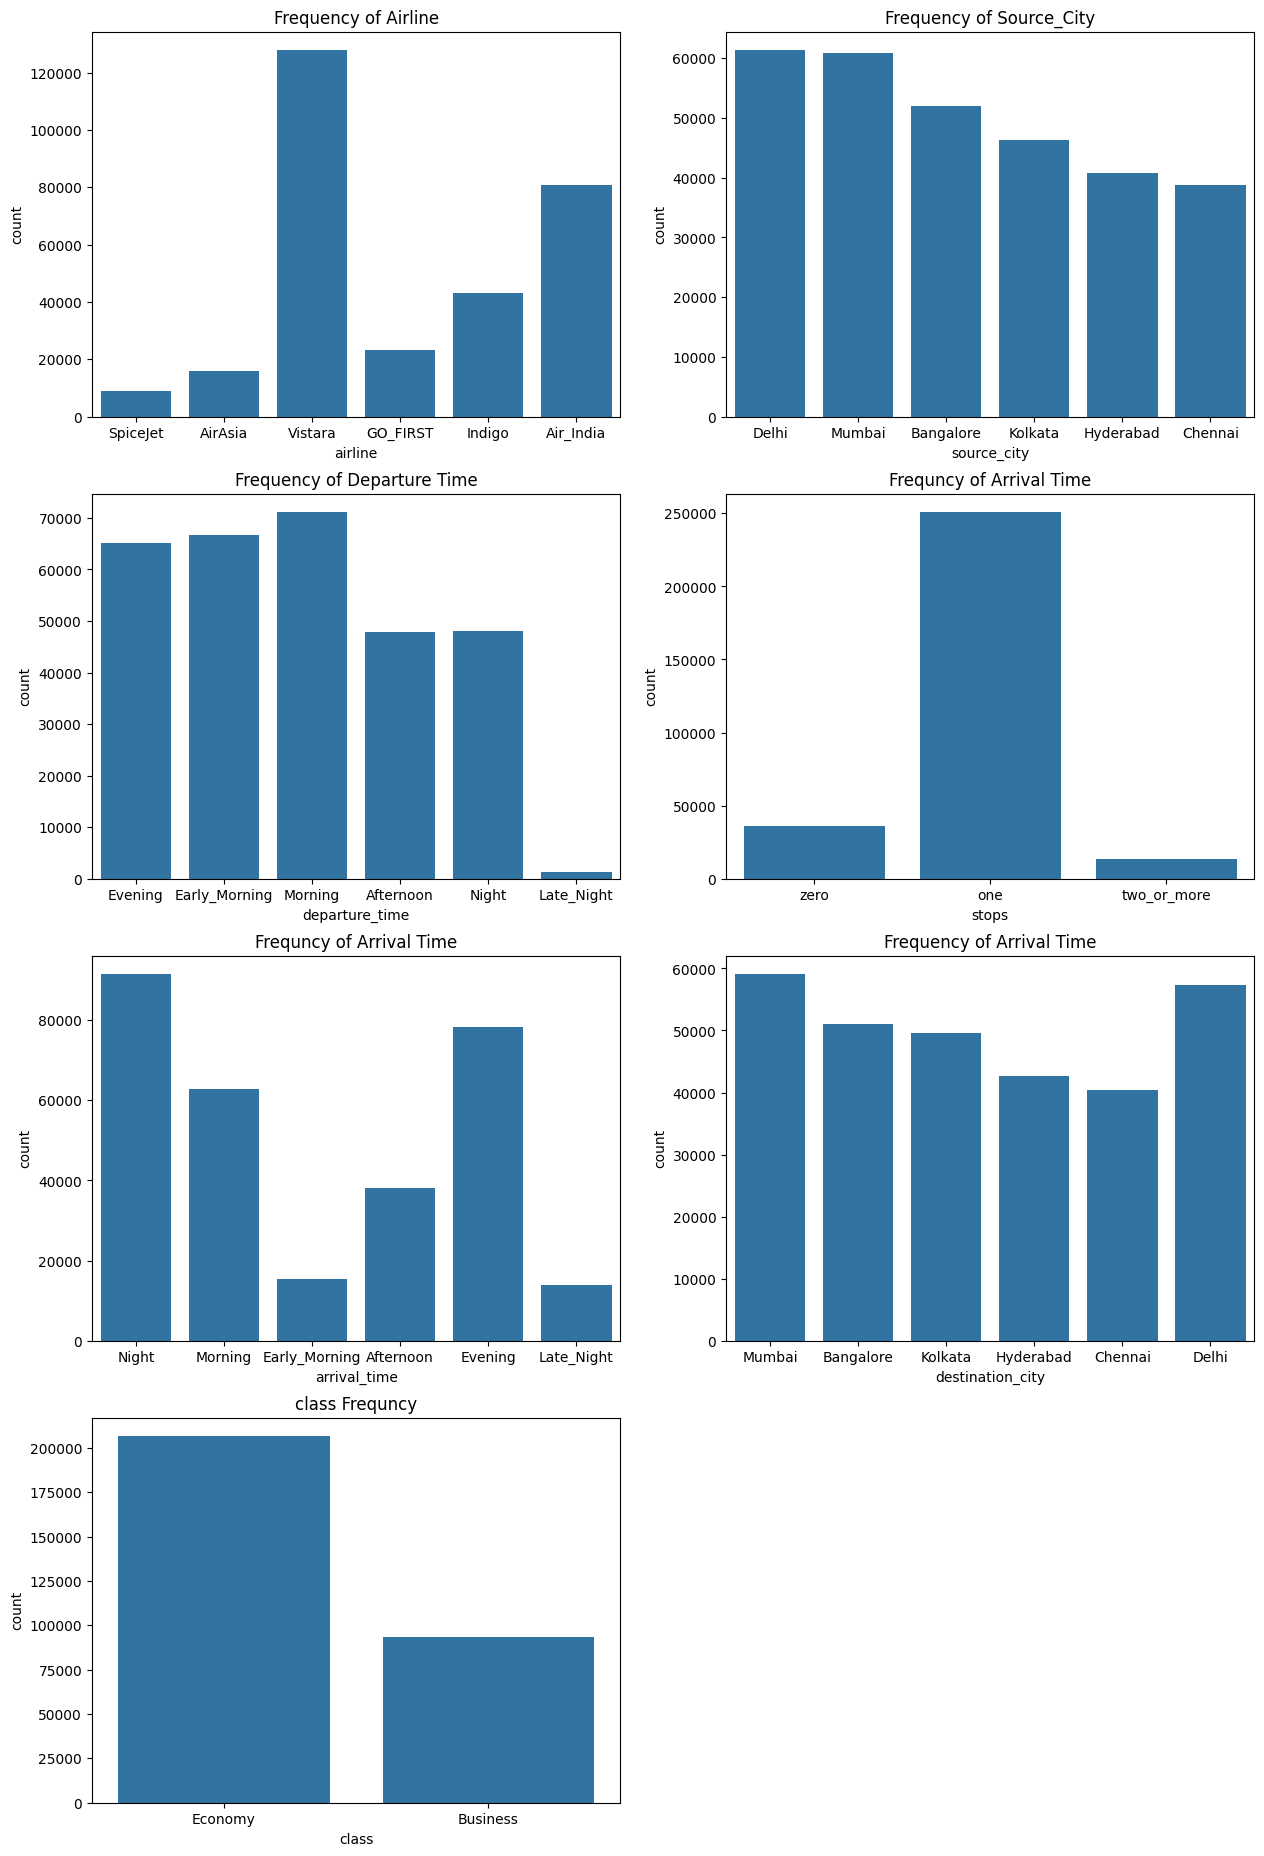

In [15]:
plt.figure(figsize=(15,23))

plt.subplot(4, 2, 1)
sns.countplot(x=df["airline"],data=df)
plt.title('Frequency of Airline')

plt.subplot(4, 2, 2)
sns.countplot(x=df['source_city'], data=df)
plt.title('Frequency of Source_City')

plt.subplot(4, 2, 3)
sns.countplot(x=df['departure_time'], data=df)
plt.title('Frequency of Departure Time')

plt.subplot(4, 2, 4)
sns.countplot(x=df["stops"], data=df)
plt.title("Frequncy of Arrival Time")

plt.subplot(4, 2, 5)
sns.countplot(x=df["arrival_time"], data=df)
plt.title("Frequncy of Arrival Time")

plt.subplot(4, 2, 6)
sns.countplot(x=df["destination_city"], data=df)
plt.title("Frequency of Arrival Time")

plt.subplot(4, 2, 7)
sns.countplot(x=df["class"], data=df)
plt.title("class Frequncy")

plt.show()

# Label Encoding

In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["airline"]=le.fit_transform(df["airline"])
df["flight"] = le.fit_transform(df["flight"])
df["source_city"]=le.fit_transform(df['source_city'])
df["departure_time"]=le.fit_transform(df['departure_time'])
df["stops"]=le.fit_transform(df['stops'])
df["arrival_time"]=le.fit_transform(df['arrival_time'])
df["destination_city"]=le.fit_transform(df['destination_city'])
df['class']=le.fit_transform(df["class"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  int64  
 1   flight            300153 non-null  int64  
 2   source_city       300153 non-null  int64  
 3   departure_time    300153 non-null  int64  
 4   stops             300153 non-null  int64  
 5   arrival_time      300153 non-null  int64  
 6   destination_city  300153 non-null  int64  
 7   class             300153 non-null  int64  
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(10)
memory usage: 25.2 MB


# Feature Selection

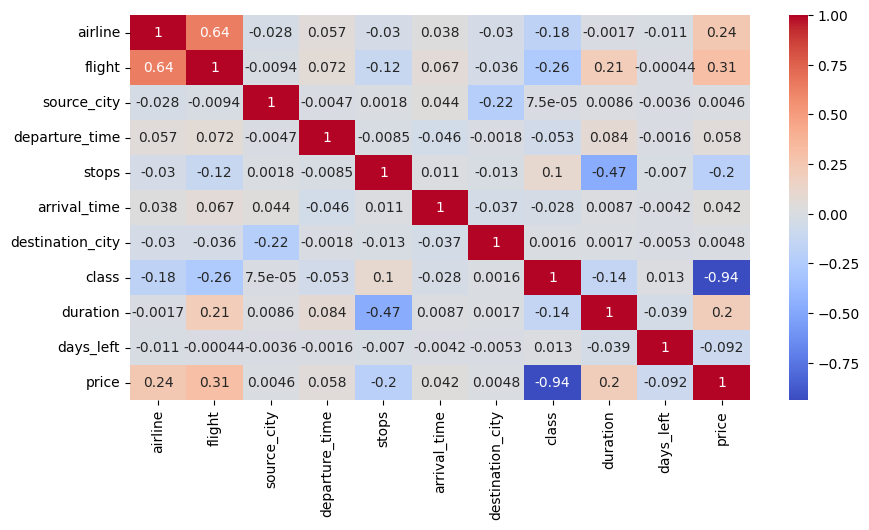

In [17]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
col_list = []
for col in df.columns:
    if ((df[col].dtype != 'object') & (col != 'price') ):
        col_list.append(col)


x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values, i)
                              for i in range(len(x.columns))]

print(vif_data)

            feature        VIF
0           airline   6.701818
1            flight  12.675046
2       source_city   2.969540
3    departure_time   2.806009
4             stops   1.437326
5      arrival_time   3.784873
6  destination_city   2.918792
7             class   2.852072
8          duration   4.754588
9         days_left   4.071591


In [19]:
df = df.drop(columns=["stops"])

from statsmodels.stats.outliers_influence import variance_inflation_factor
col_list = []
for col in df.columns:
    if ((df[col].dtype != "object") & (col != "price") ):
        col_list.append(col)

x = df[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = x.columns
vif_data['VIF'] = [variance_inflation_factor(x.values, i)
                            for i in range(len(x.columns))]

print(vif_data)

            feature        VIF
0           airline   6.701787
1            flight  12.580589
2       source_city   2.943789
3    departure_time   2.777994
4      arrival_time   3.745147
5  destination_city   2.896438
6             class   2.777535
7          duration   3.956469
8         days_left   4.053072


# Linear Regression

In [20]:
x = df.drop(columns=["price"])
y = df["price"]
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

In [21]:
from sklearn.preprocessing import StandardScaler
SC = StandardScaler()
x_train = SC.fit_transform(x_train)
x_test = SC.fit_transform(x_test)

In [22]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [23]:
y_pred = lr.predict(x_test)
difference = pd.DataFrame(np.c_[y_test,y_pred],columns=["Actual_Value", "Predicted_Value"])
difference

,Actual_Value,Predicted_Value
0,7366.0,4647.294638
1,64831.0,51686.219437
2,6195.0,6619.828946
3,60160.0,55470.733720
4,6578.0,5124.702595
...,...,...
60026,5026.0,4950.113628
60027,3001.0,4517.788696
60028,6734.0,4961.939681
60029,5082.0,2531.171003


#### Calculating r2 score,MAE, MAPE, MSE, RMSE

In [24]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.897772460824212

In [25]:
from sklearn import metrics
mean_abs_error = metrics.mean_absolute_error(y_test,y_pred)
mean_abs_error

4464.482884309702

In [26]:
from sklearn.metrics import mean_absolute_percentage_error
mean_sq_error = metrics.mean_squared_error(y_test,y_pred)
mean_sq_error

52696484.31568618

In [27]:
root_mean_sq_error = np.sqrt(metrics.mean_squared_error(y_test,y_pred))
root_mean_sq_error

np.float64(7259.234416636935)

/tmp/ipykernel_1583/1514020514.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test,label="Actual")
/tmp/ipykernel_1583/1514020514.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred,label="Predicted")


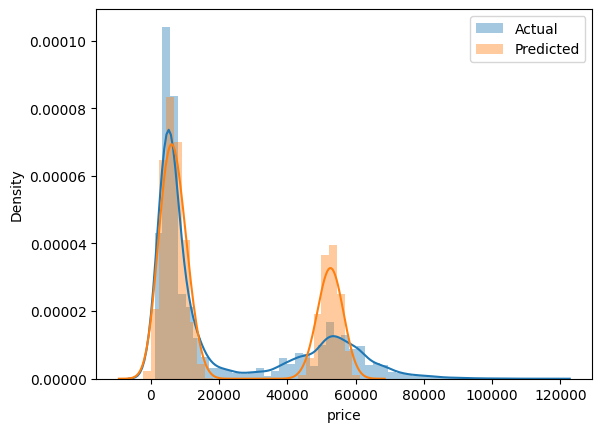

In [28]:
sns.distplot(y_test,label="Actual")
sns.distplot(y_pred,label="Predicted")
plt.legend()

# Decision Tree Regressor

In [29]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [30]:
y_pred = dt.predict(x_test)
r2_score(y_test,y_pred)

0.955400737364197

In [31]:
mean_abs_error = metrics.mean_absolute_error(y_test,y_pred)
mean_abs_error

1833.6059869067649

In [32]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y_test, y_pred)

0.10574446330751126

In [33]:
mean_sq_error = metrics.mean_squared_error(y_test,y_pred)
mean_sq_error

22990129.302999005

In [34]:
root_mean_sq_error = np.sqrt(metrics.mean_squared_error(y_test,y_pred))
root_mean_sq_error

np.float64(4794.802321576876)

# Random Forest regressor

In [35]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()
rfr.fit(x_train,y_train)

RandomForestRegressor()

In [36]:
y_pred = rfr.predict(x_test)
r2_score(y_test,y_pred)

0.9715594767781154

In [37]:
mean_abs_error = metrics.mean_absolute_error(y_test,y_pred)
mean_abs_error

1684.6243728567622

In [38]:
from sklearn.metrics import mean_absolute_percentage_error
mean_absolute_percentage_error(y_test,y_pred)
mean_sq_error

22990129.302999005

In [39]:
root_mean_sq_error = np.sqrt(metrics.mean_squared_error(y_test,y_pred))
root_mean_sq_error

np.float64(3828.914411671463)

/tmp/ipykernel_1583/1514020514.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test,label="Actual")
/tmp/ipykernel_1583/1514020514.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred,label="Predicted")


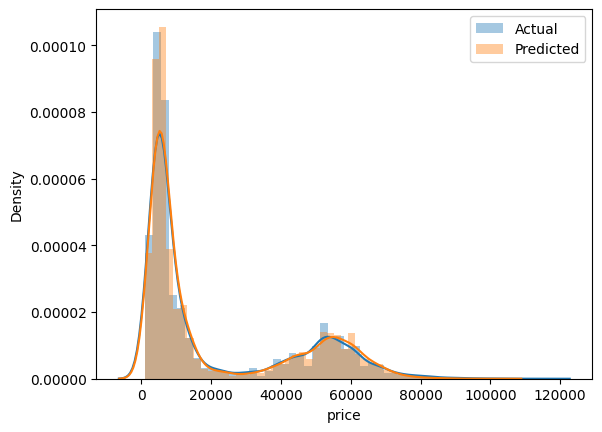

In [40]:
sns.distplot(y_test,label="Actual")
sns.distplot(y_pred,label="Predicted")
plt.legend()